In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df_output=pd.read_csv("output.csv")
df_output.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df_data=pd.read_csv("data.csv")
df_data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
print(df_output.shape)
df_output.columns 

(4600, 18)


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [6]:
print(df_data.shape)
df_data.columns 

(4600, 18)


Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [7]:
df=pd.concat([df_data,df_data], axis=0)

In [8]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [9]:
df.shape

(9200, 18)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 9200 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           9200 non-null   str    
 1   price          9200 non-null   float64
 2   bedrooms       9200 non-null   float64
 3   bathrooms      9200 non-null   float64
 4   sqft_living    9200 non-null   int64  
 5   sqft_lot       9200 non-null   int64  
 6   floors         9200 non-null   float64
 7   waterfront     9200 non-null   int64  
 8   view           9200 non-null   int64  
 9   condition      9200 non-null   int64  
 10  sqft_above     9200 non-null   int64  
 11  sqft_basement  9200 non-null   int64  
 12  yr_built       9200 non-null   int64  
 13  yr_renovated   9200 non-null   int64  
 14  street         9200 non-null   str    
 15  city           9200 non-null   str    
 16  statezip       9200 non-null   str    
 17  country        9200 non-null   str    
dtypes: float64(4), int64(9),

In [11]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

### no null values are present

In [12]:
df.duplicated().sum()

np.int64(4600)

In [13]:
df=df.drop_duplicates()

In [14]:
df.shape

(4600, 18)

### Duplicate  Data are present so removed them 

In [15]:
df["date"]=pd.to_datetime(df['date'])

In [16]:
import seaborn as sns
# sns.pairplot(df,hue="price")

<Axes: xlabel='price'>

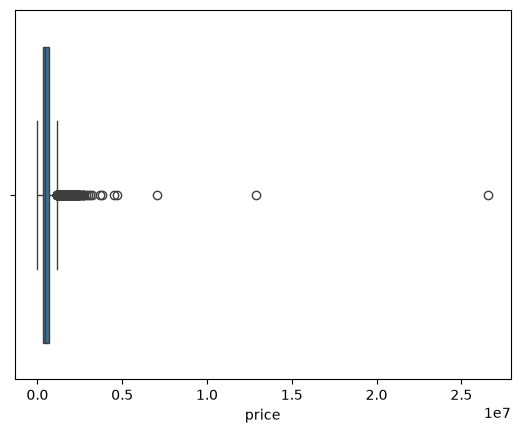

In [17]:
sns.boxplot(data=df,x="price")

In [18]:
## Handling Outliers
mean=df["price"].mean()
sd=df["price"].std()
df = df[(df["price"] < (mean + 3 * sd)) & (df["price"] > (mean - 3 * sd))]

In [19]:
len(df["price"])

4566

In [20]:
print(df["street"].unique())
len(df["street"].unique())

<StringArray>
[    '18810 Densmore Ave N', '26206-26214 143rd Ave SE',
          '857 170th Pl NE',        '9105 170th Ave NE',
           '522 NE 88th St',        '2616 174th Ave NE',
        '23762 SE 253rd Pl',  '46611-46625 SE 129th St',
         '6811 55th Ave NE',       'Burke-Gilman Trail',
 ...
         '1028 SW 307th St',        '13602 SE 186th Pl',
       '3529 SW Webster St',          '37654 18th Pl S',
       '26306 127th Ave SE',           '501 N 143rd St',
         '14855 SE 10th Pl',         '759 Ilwaco Pl NE',
        '5148 S Creston St',        '18717 SE 258th St']
Length: 4492, dtype: str


4492

## more number of unique value. so i have to do target encoding

In [21]:
stret_mean=df.groupby("street")['price'].mean()
stret_mean=stret_mean.to_dict()

In [22]:
df["street"]=df["street"].map(stret_mean)

In [23]:
df["street"]

0       313000.000000
2       342000.000000
3       420000.000000
4       550000.000000
5       490000.000000
            ...      
4595    308166.666667
4596    534333.333333
4597    416904.166667
4598    203400.000000
4599    220600.000000
Name: street, Length: 4566, dtype: float64

In [24]:
len(df["city"].unique())

44

In [25]:
city_count=df["city"].value_counts(ascending=False)
city_count

city
Seattle                1560
Renton                  293
Bellevue                282
Redmond                 234
Issaquah                187
Kirkland                185
Kent                    184
Auburn                  176
Sammamish               174
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            81
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
Tukwila                  29
Vashon                   29
SeaTac                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Fall City                11
Black Diamond             9
Clyde Hill                9
Ravensdale                7
Medina                    6
Pacific        

In [26]:
top_10_city=[item for item in city_count.iloc[:10].index]
top_10_city

['Seattle',
 'Renton',
 'Bellevue',
 'Redmond',
 'Issaquah',
 'Kirkland',
 'Kent',
 'Auburn',
 'Sammamish',
 'Federal Way']

In [27]:
for feature in top_10_city:
    df[feature + "_Encoding"]=np.where(df["city"]==feature,1,0)

In [28]:
df.drop("city",axis=1,inplace=True)
df.shape

(4566, 27)

In [29]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,Seattle_Encoding,Renton_Encoding,Bellevue_Encoding,Redmond_Encoding,Issaquah_Encoding,Kirkland_Encoding,Kent_Encoding,Auburn_Encoding,Sammamish_Encoding,Federal Way_Encoding
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,0,0,0,0,0,0,0,0,0,0
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0,0,0,0,0,0,1,0,0,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0,0,1,0,0,0,0,0,0,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,0,0,0,1,0,0,0,0,0,0
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,...,1,0,0,0,0,0,0,0,0,0


In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 4566 entries, 0 to 4599
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  4566 non-null   datetime64[us]
 1   price                 4566 non-null   float64       
 2   bedrooms              4566 non-null   float64       
 3   bathrooms             4566 non-null   float64       
 4   sqft_living           4566 non-null   int64         
 5   sqft_lot              4566 non-null   int64         
 6   floors                4566 non-null   float64       
 7   waterfront            4566 non-null   int64         
 8   view                  4566 non-null   int64         
 9   condition             4566 non-null   int64         
 10  sqft_above            4566 non-null   int64         
 11  sqft_basement         4566 non-null   int64         
 12  yr_built              4566 non-null   int64         
 13  yr_renovated          4566 non-nul

In [31]:
df["country"].unique()

<StringArray>
['USA']
Length: 1, dtype: str

### Here Usa is one one country. So there is no Significane of country columns in Training a model

In [32]:
df.drop(labels="country", axis=1,inplace=True)

In [33]:
print(df.shape)
df.head()

(4566, 26)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,Seattle_Encoding,Renton_Encoding,Bellevue_Encoding,Redmond_Encoding,Issaquah_Encoding,Kirkland_Encoding,Kent_Encoding,Auburn_Encoding,Sammamish_Encoding,Federal Way_Encoding
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,0,0,0,0,0,0,0,0,0,0
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0,0,0,0,0,0,1,0,0,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0,0,1,0,0,0,0,0,0,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,0,0,0,1,0,0,0,0,0,0
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,...,1,0,0,0,0,0,0,0,0,0


In [34]:
len(df["statezip"].unique())

77

In [35]:
count_statezip=df.groupby("statezip")["price"].mean().to_dict()
print(count_statezip)
df["statezip"]=df["statezip"].map(count_statezip)

{'WA 98001': 257734.8017057612, 'WA 98002': 223547.30555555556, 'WA 98003': 299425.625, 'WA 98004': 1121947.031884058, 'WA 98005': 778779.1839080345, 'WA 98006': 793052.634090909, 'WA 98007': 639103.4188034103, 'WA 98008': 560166.4285714285, 'WA 98010': 339605.55555555556, 'WA 98011': 483518.203125, 'WA 98014': 508751.95454545453, 'WA 98019': 403994.12698411907, 'WA 98022': 307614.58333332144, 'WA 98023': 287306.41253131576, 'WA 98024': 692681.8181818182, 'WA 98027': 581749.9894736842, 'WA 98028': 447009.0547263582, 'WA 98029': 618453.0883838409, 'WA 98030': 279973.9384436586, 'WA 98031': 284038.29337606154, 'WA 98032': 261342.47619047618, 'WA 98033': 795004.0170454546, 'WA 98034': 475620.18557973474, 'WA 98038': 336474.9118055521, 'WA 98039': 1440500.0, 'WA 98040': 1010374.806584358, 'WA 98042': 320243.96857143, 'WA 98045': 399565.70666666003, 'WA 98047': 225233.33333333334, 'WA 98050': 562450.0, 'WA 98051': 514071.4285714286, 'WA 98052': 637555.7193672815, 'WA 98053': 691975.44906191

In [36]:
# Check dtype other than float64,int64,int32,float32
suitable_dtype=["float64","int64","int32","float32"]
other_dtype_col=[item for item in df.columns if df[item].dtype not in suitable_dtype]
other_dtype_col

['date']

### Analysis price with DateTime

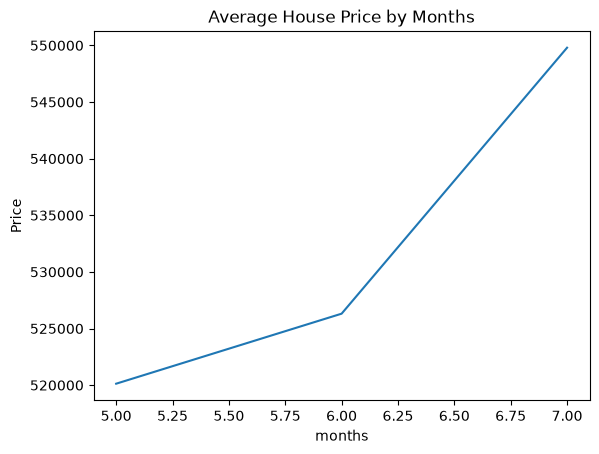

In [37]:
## plot price mean vs months

df["months"]=df["date"].dt.month
df.groupby('months')['price'].mean().plot(kind="line")
plt.title('Average House Price by Months')
plt.ylabel('Price')
plt.show()

<Axes: xlabel='months', ylabel='count'>

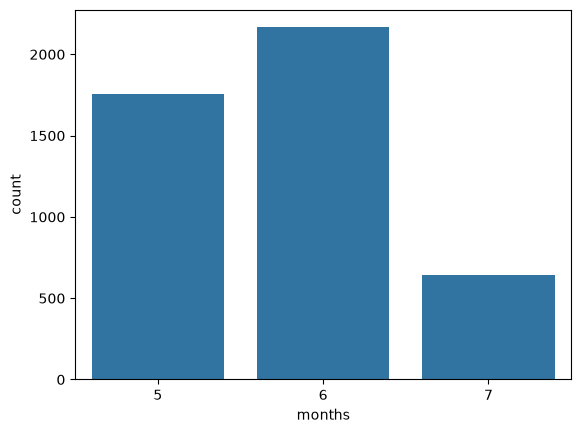

In [38]:
sns.countplot(x ='months', data = df)   ## count plot

## more houses are sold at months 6
## But mean of price at months 7 is high. So, We can conclude that Price are Higher at months 7.

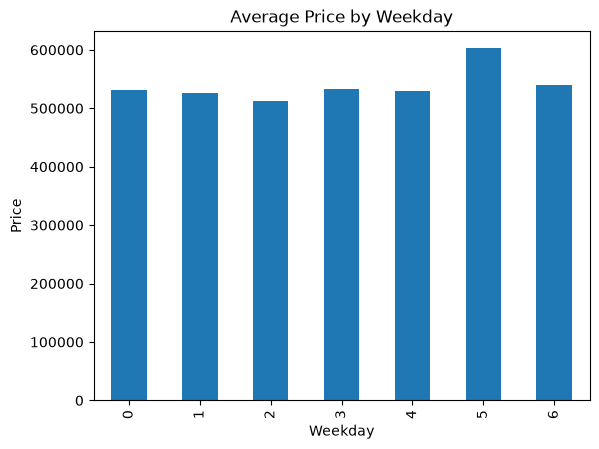

In [39]:
# With Week
df["Weekday"]=df["date"].dt.weekday
df.groupby('Weekday')['price'].mean().plot(kind='bar')
plt.title('Average Price by Weekday')
plt.ylabel('Price')
plt.show()

In [40]:
df["daysSince"]=(df['date'] - pd.Timestamp.now()).dt.days

In [41]:
df["daysSince"].value_counts().sort_index()

daysSince
-4442     66
-4441      4
-4440      5
-4439     83
-4438     83
        ... 
-4377      3
-4376     83
-4375    126
-4374    119
-4373     31
Name: count, Length: 70, dtype: int64

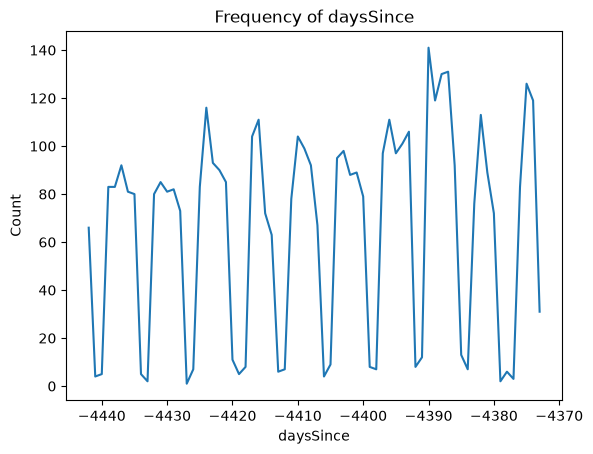

In [42]:
df["daysSince"].value_counts().sort_index().plot(kind='line')
plt.xlabel("daysSince")
plt.ylabel("Count")
plt.title("Frequency of daysSince")
plt.show()

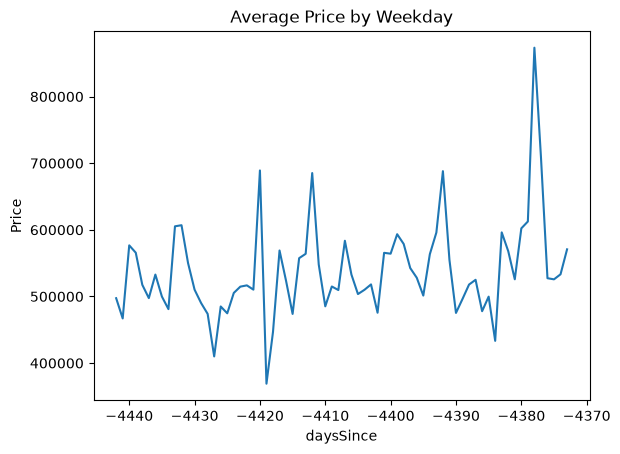

In [43]:
df.groupby('daysSince')['price'].mean().plot(kind='line')
plt.title('Average Price by Weekday')
plt.ylabel('Price')
plt.show()

## Conclusion : More price for new House than old one 

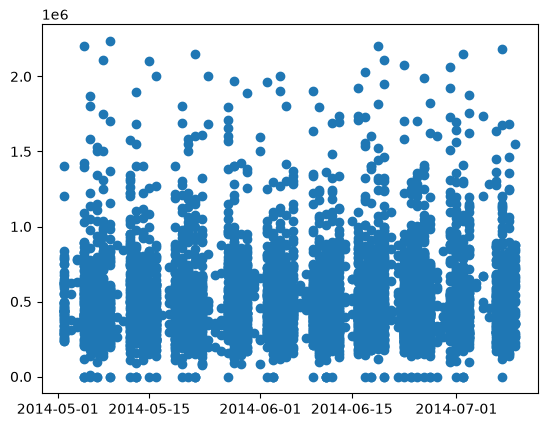

In [44]:
plt.scatter(df['date'], df['price'])
plt.show()

In [45]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'statezip',
       'Seattle_Encoding', 'Renton_Encoding', 'Bellevue_Encoding',
       'Redmond_Encoding', 'Issaquah_Encoding', 'Kirkland_Encoding',
       'Kent_Encoding', 'Auburn_Encoding', 'Sammamish_Encoding',
       'Federal Way_Encoding', 'months', 'Weekday', 'daysSince'],
      dtype='str')

In [46]:
#how old the house is 
df["Age_of_house"]=df["date"].dt.year- df["yr_built"]
df["Age_of_house"]

0       59
2       48
3       51
4       38
5       76
        ..
4595    60
4596    31
4597     5
4598    40
4599    24
Name: Age_of_house, Length: 4566, dtype: int64

<Axes: xlabel='Age_of_house'>

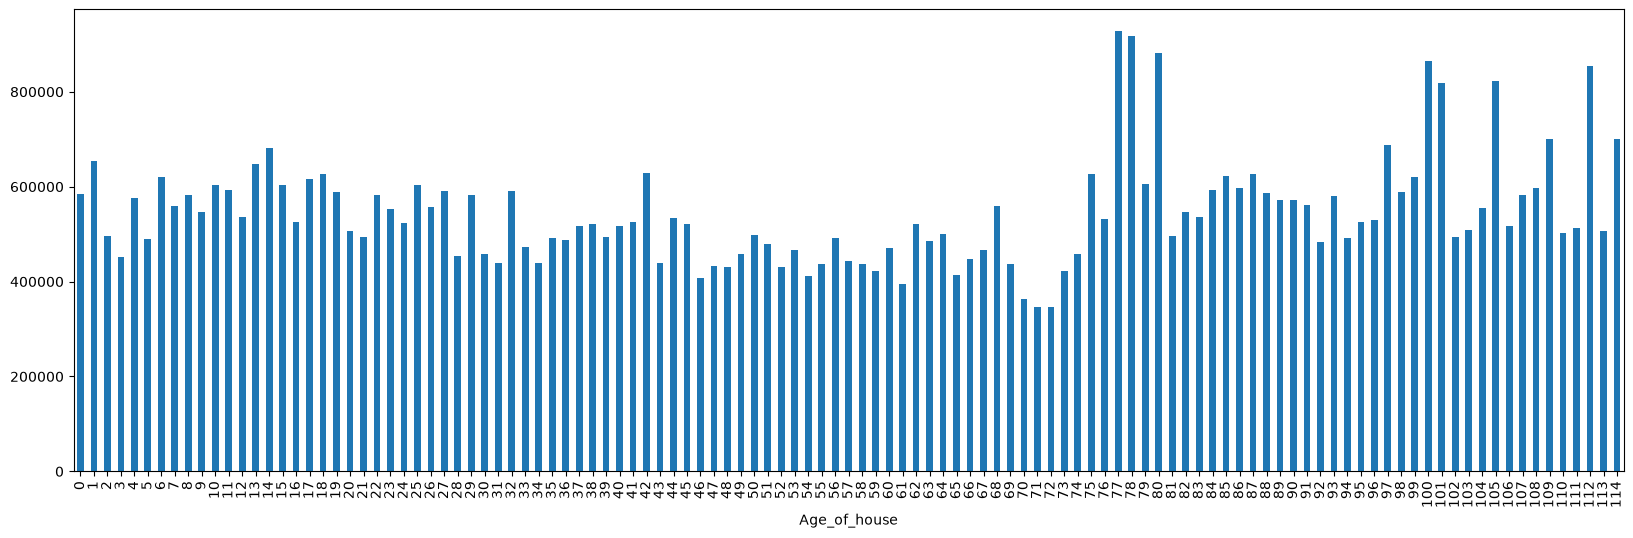

In [47]:
plt.figure(figsize=(20, 6))
df.groupby("Age_of_house")["price"].mean().plot(kind="bar")

<Axes: xlabel='Age_of_house'>

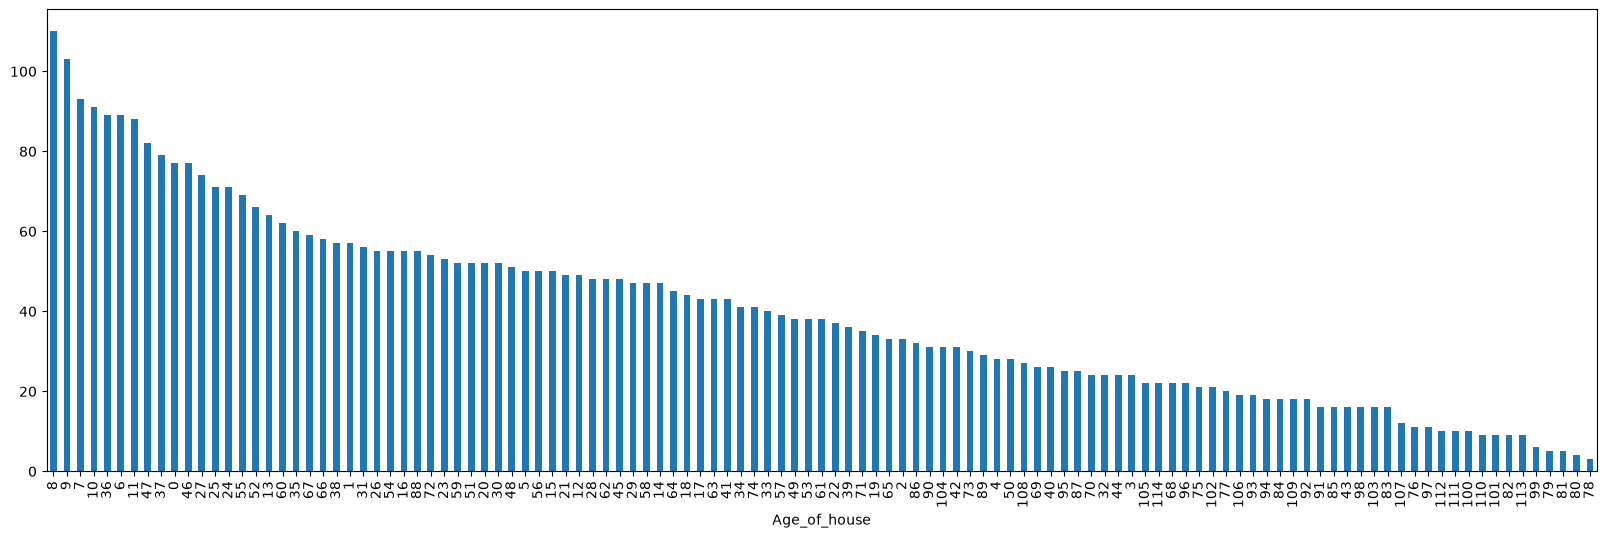

In [48]:
plt.figure(figsize=(20, 6))
df["Age_of_house"].value_counts().plot(kind="bar")

## New Houses Are sold more than old one

## For Year Reinoveted

In [49]:
df['yr_renovated'].unique()

array([2005,    0, 1992, 1994, 2010, 1988, 2009, 1969, 2000, 1979, 1989,
       2014, 1999, 2003, 1983, 1997, 1912, 1923, 1954, 2011, 2001, 2013,
       2006, 1972, 1985, 1998, 2004, 1958, 2008, 1970, 1982, 1986, 1996,
       2002, 1971, 1990, 1956, 1945, 1984, 2012, 1993, 2007, 1981, 1974,
       1963, 1968, 1995, 1934, 1953, 1966, 1955, 1987, 1960, 1978, 1980,
       1948, 1991, 1913, 1977, 1975])

# Here this feature contain 0 value which is irtrevelent. So, make this relevent 

<Axes: xlabel='yr_renovated'>

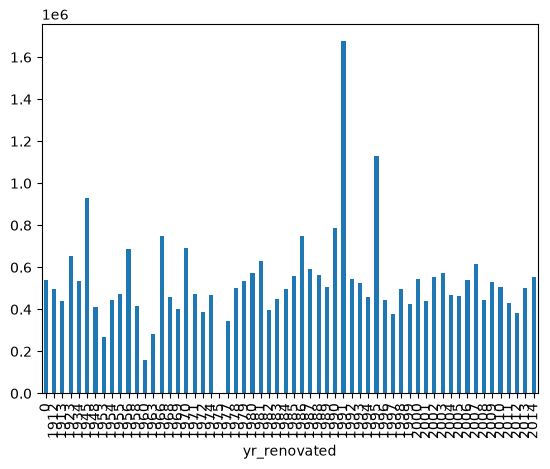

In [50]:
# plt.figure(figsize=(20,10))
df.groupby("yr_renovated")["price"].mean().plot(kind="bar")

In [51]:
df["yr_renovated"]=df["yr_renovated"].replace(0,np.nan)

In [52]:
df['yr_renovated']=df['yr_renovated'].astype("object")
df['yr_renovated'].dtype

dtype('O')

In [53]:
df['yr_renovated']=df["yr_renovated"].fillna(df["yr_renovated"].mode()[0])
df['yr_renovated'].unique()

array([2005.0, 2000.0, 1992.0, 1994.0, 2010.0, 1988.0, 2009.0, 1969.0,
       1979.0, 1989.0, 2014.0, 1999.0, 2003.0, 1983.0, 1997.0, 1912.0,
       1923.0, 1954.0, 2011.0, 2001.0, 2013.0, 2006.0, 1972.0, 1985.0,
       1998.0, 2004.0, 1958.0, 2008.0, 1970.0, 1982.0, 1986.0, 1996.0,
       2002.0, 1971.0, 1990.0, 1956.0, 1945.0, 1984.0, 2012.0, 1993.0,
       2007.0, 1981.0, 1974.0, 1963.0, 1968.0, 1995.0, 1934.0, 1953.0,
       1966.0, 1955.0, 1987.0, 1960.0, 1978.0, 1980.0, 1948.0, 1991.0,
       1913.0, 1977.0, 1975.0], dtype=object)

In [54]:
df["Time_afetr_renonated"]=df["date"].dt.year-df["yr_renovated"]
df["Time_afetr_renonated"]

0        9.0
2       14.0
3       14.0
4       22.0
5       20.0
        ... 
4595    35.0
4596     5.0
4597    14.0
4598    14.0
4599    14.0
Name: Time_afetr_renonated, Length: 4566, dtype: object

<Axes: xlabel='Time_afetr_renonated'>

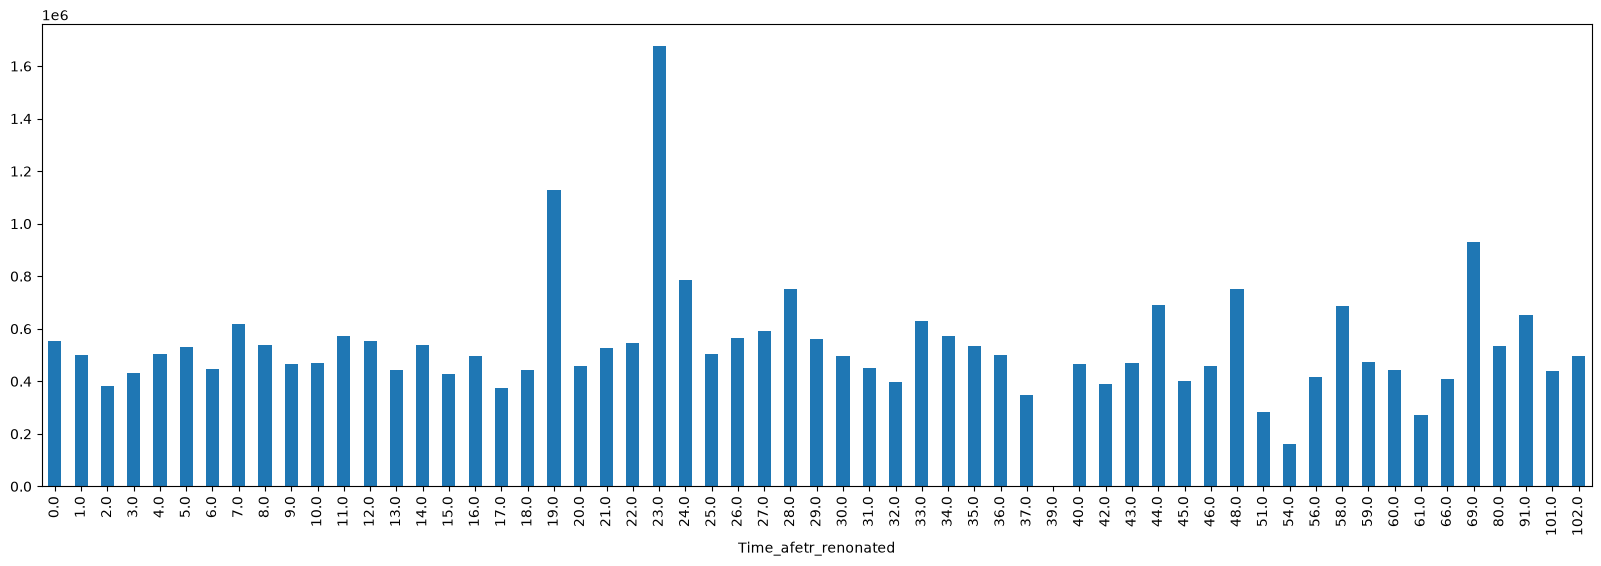

In [55]:
plt.figure(figsize=(20, 6))
df.groupby("Time_afetr_renonated")["price"].mean().plot(kind="bar")

## newly renovated house can be sold at high Price

## Here Feaature like yr_built and Yr_renovated are no important as we have age_of houe and Time after reinovated. So drop Them

In [56]:
df.drop(['yr_renovated','yr_built'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 4566 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  4566 non-null   datetime64[us]
 1   price                 4566 non-null   float64       
 2   bedrooms              4566 non-null   float64       
 3   bathrooms             4566 non-null   float64       
 4   sqft_living           4566 non-null   int64         
 5   sqft_lot              4566 non-null   int64         
 6   floors                4566 non-null   float64       
 7   waterfront            4566 non-null   int64         
 8   view                  4566 non-null   int64         
 9   condition             4566 non-null   int64         
 10  sqft_above            4566 non-null   int64         
 11  sqft_basement         4566 non-null   int64         
 12  street                4566 non-null   float64       
 13  statezip              4566 non-nul

## Analysis Price With Number of Bedroom

In [57]:
df["bedrooms"].unique()

array([3., 4., 2., 5., 6., 9., 1., 7., 8., 0.])

## Here, We see that There are 0 bedrooms. in any house thre must atleast one or more bedrooms

<Axes: xlabel='bedrooms'>

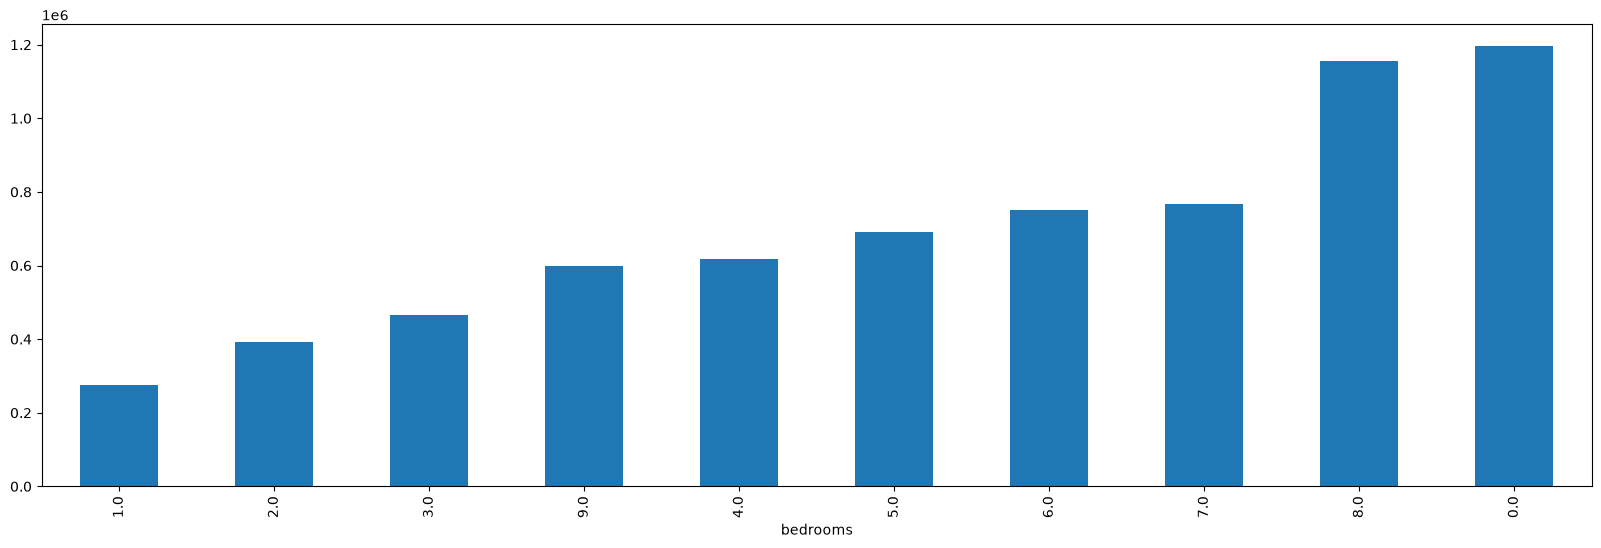

In [58]:
plt.figure(figsize=(20, 6))
df.groupby("bedrooms")["price"].mean().sort_values().plot(kind="bar")

## Here we see that for zero bedrooms But the mean price is High. this is impossible so there must be higher number of bet for this

In [59]:
df["bedrooms"]=df["bedrooms"].replace(0,9)

<Axes: xlabel='bedrooms'>

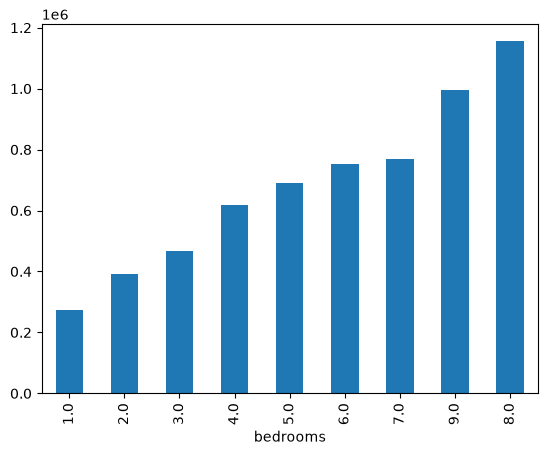

In [60]:
# plt.figure(figsize=(20,10))
df.groupby("bedrooms")["price"].mean().sort_values().plot(kind="bar")

In [61]:
df["bathrooms"].unique()

array([1.5 , 2.  , 2.25, 2.5 , 1.  , 1.75, 2.75, 3.  , 3.25, 3.5 , 4.25,
       4.  , 3.75, 5.  , 4.5 , 5.75, 1.25, 6.5 , 4.75, 0.75, 5.25, 5.5 ,
       0.  , 6.25])

<Axes: xlabel='bathrooms'>

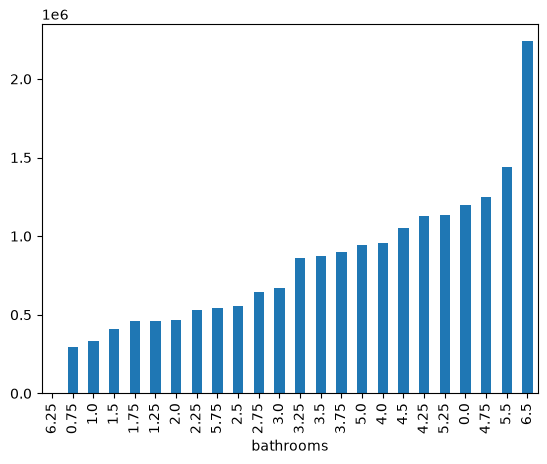

In [62]:
# plt.figure(figsize=(20,10))
df.groupby("bathrooms")["price"].mean().sort_values().plot(kind="bar")

## not possible that a house has no bathrooms

In [63]:
df["bathrooms"]=df["bathrooms"].replace(0,6.25)

<Axes: xlabel='bathrooms'>

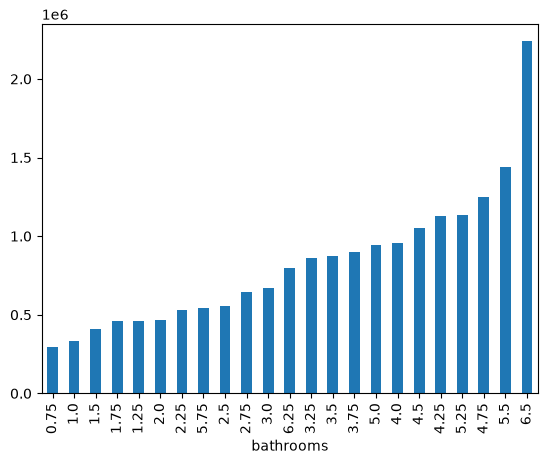

In [64]:
# plt.figure(figsize=(20,10))
df.groupby("bathrooms")["price"].mean().sort_values().plot(kind="bar")

In [65]:
df["sqft_living"].unique()

array([1340, 1930, 2000, 1940,  880, 1350, 2710, 2430, 1520, 1710, 2920,
       2330, 1090, 2910, 1200, 1570, 3110, 1370, 1180, 2240, 1450, 1750,
       2730, 1600, 2090, 2360, 2200, 2820, 2600, 1560, 2860, 1820, 3630,
       3240,  800, 1850, 1960, 2390, 1580, 1480,  850, 1770, 1210, 1160,
       1970, 1270, 3310, 1800, 2210, 1920, 2190, 3660, 1320, 1630, 2680,
       2540,  900, 1650, 1010, 2530, 2850, 2280, 1900, 1330, 2170, 2120,
       2490, 1990, 3690, 2340, 2110, 1140, 1410, 3180, 2160, 2350, 2740,
       1680, 3090, 4010, 2010, 2370, 1840, 2070, 4340,  840, 1240, 1390,
       2310, 1050, 2550, 1120, 2230,  810, 3190, 1670, 1880, 1550, 2050,
       2220, 2300, 1790, 2440, 3400, 4420, 1571, 1620, 1408, 3040, 4490,
       1590, 2450, 1440, 1100, 2150, 1490, 1030,  720, 2020, 1300, 3370,
       1890, 1260, 3470, 2290, 2810, 1640, 1500, 2460, 1230, 2331, 3100,
       2060, 3740, 1420, 1510, 2130, 3490, 2260, 3030, 1310, 3880, 3760,
       2970, 1660, 3200, 3380, 1110,  930, 1690, 45

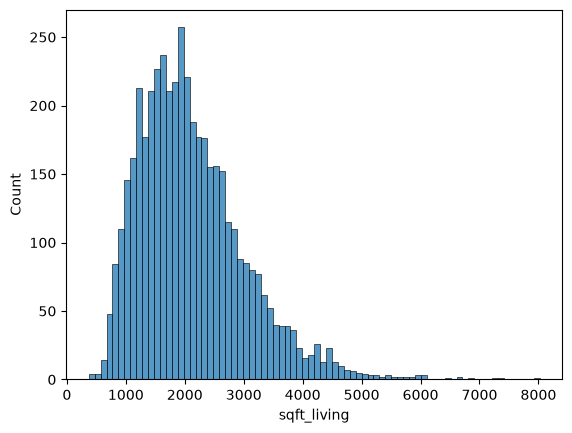

In [66]:
sns.histplot(data=df, x='sqft_living', binwidth=100)
plt.show()

In [67]:
np.sort(df["sqft_lot"].unique())[::-1][:10]

array([1074218,  641203,  478288,  435600,  423838,  389126,  327135,
        306848,  284011,  280962])

In [68]:
sqft_range = df["sqft_lot"].max() - df["sqft_lot"].min()
print(df["sqft_lot"].max())
print(df["sqft_lot"].min())
print(sqft_range)

1074218
638
1073580


## squarefeet cant be so hifher as 1074218

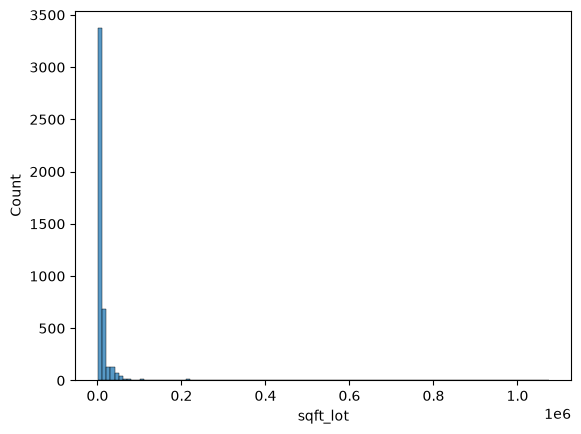

In [69]:
sns.histplot(data=df, x='sqft_lot', binwidth=10000)
plt.show()

In [70]:
np.sort(df["floors"].unique())

array([1. , 1.5, 2. , 2.5, 3. , 3.5])

<Axes: xlabel='floors'>

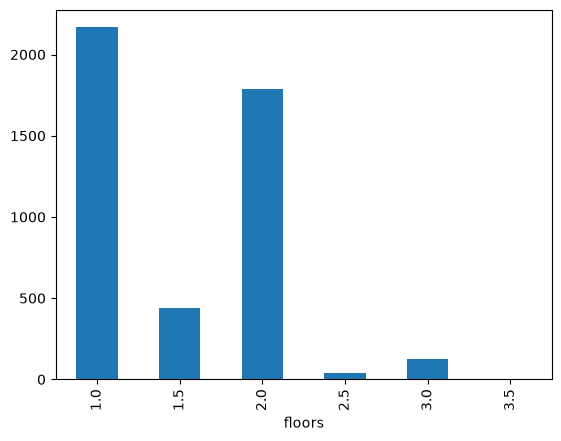

In [71]:
df.groupby("floors")["floors"].value_counts(ascending=True).plot(kind="bar")

<Axes: xlabel='floors'>

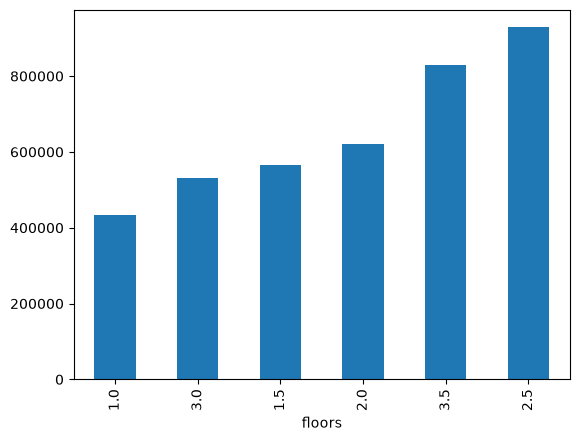

In [72]:
df.groupby("floors")["price"].mean().sort_values().plot(kind="bar")

In [73]:
np.sort(df["waterfront"].unique())

array([0, 1])

<Axes: xlabel='waterfront'>

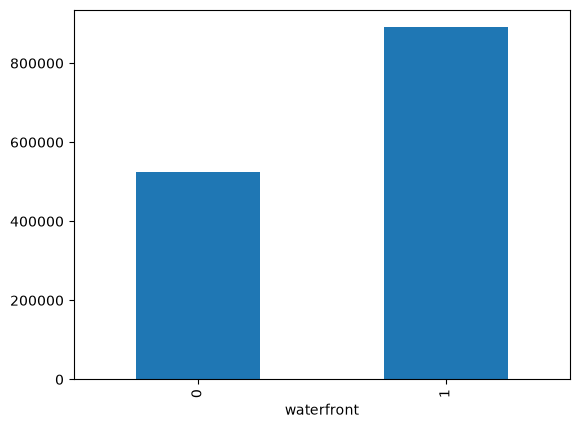

In [74]:
df.groupby("waterfront")["price"].mean().sort_values().plot(kind="bar")

## Conclusion : if water front is present price is High

In [75]:
df["view"].unique()

array([0, 1, 2, 3, 4])

<Axes: xlabel='view'>

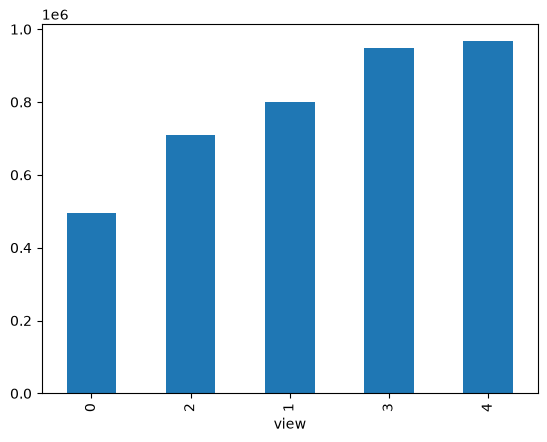

In [76]:
df.groupby("view")["price"].mean().sort_values().plot(kind="bar")

In [77]:
df["condition"].unique()

array([3, 4, 5, 2, 1])

<Axes: xlabel='condition'>

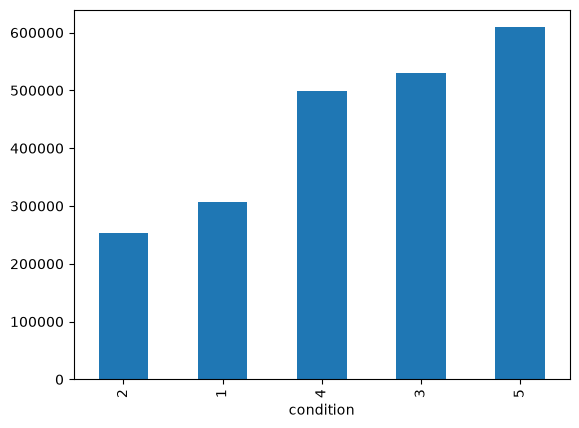

In [78]:
df.groupby("condition")["price"].mean().sort_values().plot(kind="bar")

In [79]:
df.drop("date", axis=1,inplace=True)

In [80]:
X=df.drop("price",axis=1)
y=df["price"]

In [81]:
#Train test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.3)

In [82]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled=scaler.fit_transform(x_train)
scaled_train_df=pd.DataFrame(scaled,columns=x_train.columns)

In [83]:
scaled_train_df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,Kirkland_Encoding,Kent_Encoding,Auburn_Encoding,Sammamish_Encoding,Federal Way_Encoding,months,Weekday,daysSince,Age_of_house,Time_afetr_renonated
0,-1.507664,-1.477089,-0.866579,-0.144258,-0.952646,-0.068669,-0.305564,-0.661306,-1.037936,0.193810,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,0.341200,-1.377346,1.146579,1.747864,-0.233703
1,0.672650,0.441016,0.497827,-0.265639,0.889252,-0.068669,-0.305564,-0.661306,0.887432,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,0.341200,-0.690714,0.485353,-0.966115,-0.161446
2,0.672650,0.760700,-0.397223,-0.303889,-0.031697,-0.068669,-0.305564,-0.661306,-0.081158,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,0.341200,0.682550,0.943125,2.283959,-0.522728
3,-1.507664,-0.518037,-0.659189,-0.307156,-0.952646,-0.068669,-0.305564,-0.661306,-0.364648,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,0.341200,-1.377346,1.146579,-1.167151,-0.161446
4,0.672650,0.441016,0.705217,-0.246073,0.889252,-0.068669,-0.305564,-0.661306,1.111861,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,-1.128442,0.682550,-0.481056,-0.932609,-0.161446


In [84]:
scaled_test_df=pd.DataFrame(scaler.transform(x_test),columns=x_train.columns)
scaled_test_df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,Kirkland_Encoding,Kent_Encoding,Auburn_Encoding,Sammamish_Encoding,Federal Way_Encoding,months,Weekday,daysSince,Age_of_house,Time_afetr_renonated
0,-0.417507,-0.518037,-0.626444,-0.063283,-0.952646,-0.068669,-0.305564,2.326021,-0.329212,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,-1.128442,-0.004082,-0.887965,0.139580,-0.161446
1,0.672650,1.080385,0.053577,-0.277660,0.889252,-0.068669,-0.305564,-0.661306,0.406680,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,-1.128442,1.369182,-1.498328,-1.167151,-0.161446
2,-0.417507,-1.477089,-1.172206,-0.204328,-0.952646,-0.068669,-0.305564,-0.661306,-0.919815,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,0.341200,2.055815,1.044852,-0.396515,-0.811754
3,-0.417507,0.441016,-0.080681,-0.318686,0.889252,-0.068669,-0.305564,-0.661306,0.261392,-0.674761,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,0.341200,1.369182,0.281898,-0.698068,-0.161446
4,-0.417507,-0.518037,-0.244410,-0.344883,-0.952646,-0.068669,-0.305564,-0.661306,-0.624513,0.696666,...,-0.203425,-0.203425,-0.195797,-0.201751,-0.178792,-1.128442,-1.377346,-0.989692,-0.094961,-0.161446


# train a model

In [85]:
from sklearn.linear_model import LinearRegression
linear=LinearRegression()
linear.fit(scaled_train_df,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](27,)","[-235.35, 158.49,1320.07,...,1384.53, -57.66,-294.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](27,)","['bedrooms','bathrooms','sqft_living',...,'daysSince','Age_of_house', 'Time_afetr_renonated']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.324e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,26


In [86]:
# make prediction
y_pred=linear.predict(scaled_test_df)

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


MAE: 3035.9954179310653
RMSE: 9702.975374908046
R2: 0.9988437895303313


In [88]:
#Intercept Cofficiont
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear.coef_
}).sort_values(by='Coefficient', ascending=False)


In [89]:
coef_df

,Feature,Coefficient
10,street,309816.523747
5,waterfront,2713.247732
12,Seattle_Encoding,1414.517804
24,daysSince,1384.531933
2,sqft_living,1320.071116
8,sqft_above,1117.576036
11,statezip,898.409198
9,sqft_basement,601.717457
14,Bellevue_Encoding,589.372226
4,floors,547.862895


In [90]:
#cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(linear, x_train, y_train, cv=5, scoring='r2')
scores.mean()

np.float64(0.9960754598964613)

## here, cross validation score is hidh. so , may be data leakage or overfitting most probably

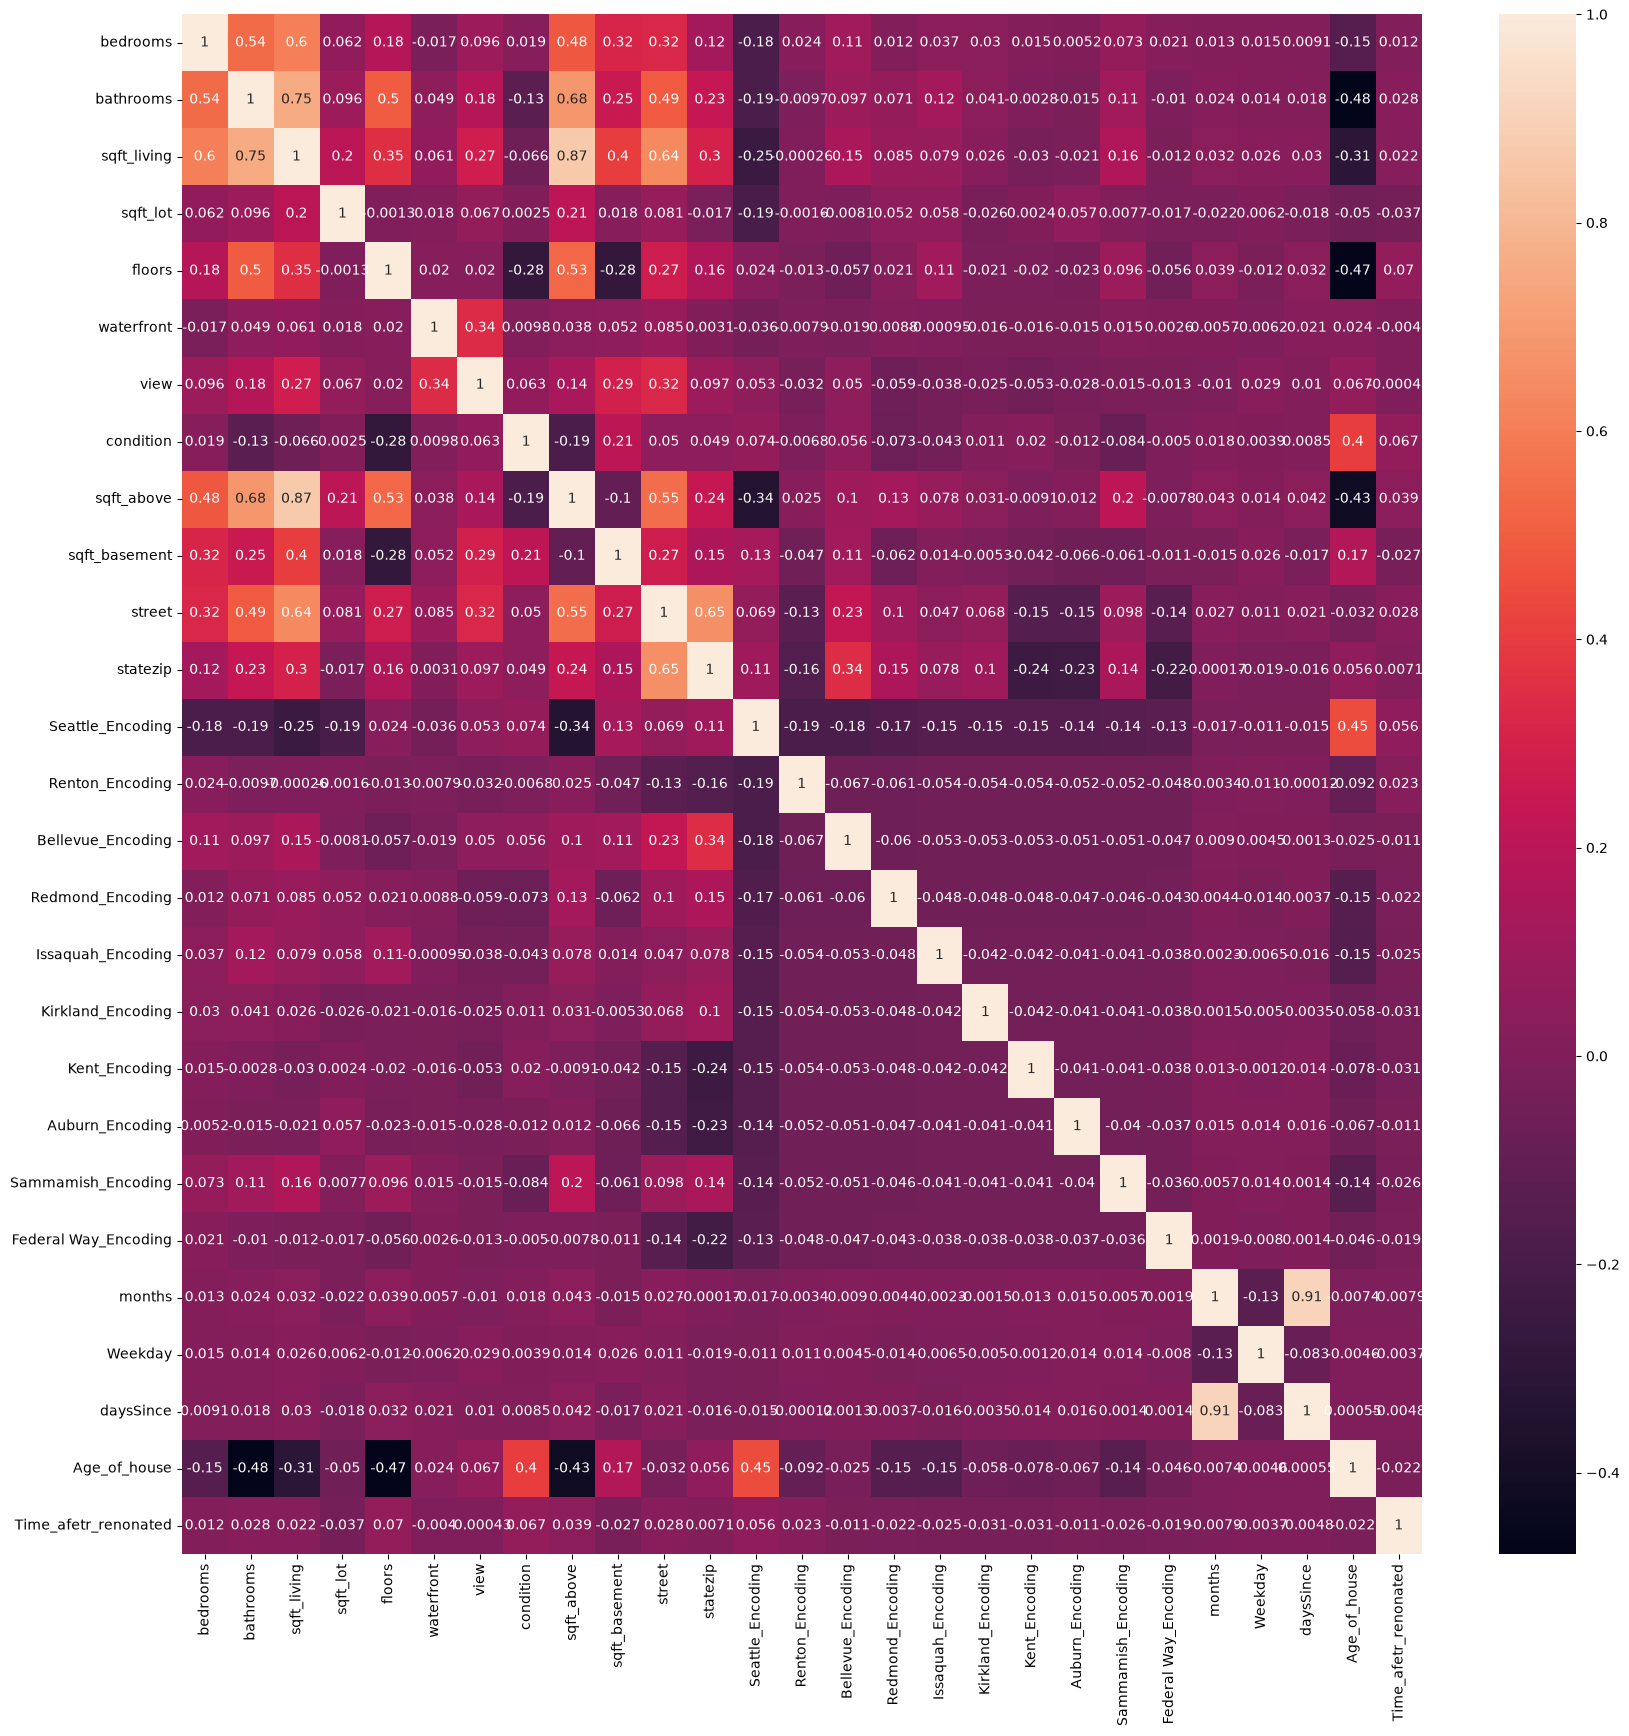

In [91]:
plt.figure(figsize=(20, 20))
sns.heatmap(X.corr(), annot=True)
plt.show()

## Here, some feature are highly correlated. so, this cause Daya Leakage. So, Remove all High correlated Feature

In [92]:
def high_correlated_feature(dataset,threshold):
    corr_matrix=dataset.corr()
    corr_feature=set()
    for i in range(len(corr_matrix.columns)): 
        for j in range(i): 
            if abs(corr_matrix.iloc[i,j])>threshold: 
                feature=corr_matrix.columns[i]
                corr_feature.add(feature)

    return corr_feature

In [93]:
high_corr_feature=high_correlated_feature(x_train,0.85)
high_corr_feature

{'daysSince', 'sqft_above'}

In [94]:
scaled_train_df.drop(high_corr_feature,axis=1,inplace=True)
x_train.drop(high_corr_feature,axis=1,inplace=True)

In [95]:
scaled_test_df.drop(high_corr_feature,axis=1,inplace=True)
x_test.drop(high_corr_feature,axis=1,inplace=True)

In [96]:
##Again Train a model after removing Highly correlated values
from sklearn.linear_model import LinearRegression
linear=LinearRegression()
linear.fit(scaled_train_df,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](25,)","[-239.55, 145.71,2551.19,...,-458.25, -32.91,-288.89]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](25,)","['bedrooms','bathrooms','sqft_living',...,'Weekday','Age_of_house', 'Time_afetr_renonated']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.324e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,25
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,25


In [97]:
y_pred=linear.predict(scaled_test_df)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 2957.064314753621
RMSE: 9665.08419556496
R2: 0.9988528021547702


In [98]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# CV score
cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='r2')
print(f"CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Train and test
pipeline.fit(x_train, y_train)
train_r2 = pipeline.score(x_train, y_train)
test_r2 = pipeline.score(x_test, y_test)

print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# All three should be similar (~0.996)
# Big gaps = overfitting

CV R²: 0.9960 (+/- 0.0044)
Train R²: 0.9961
Test R²: 0.9989


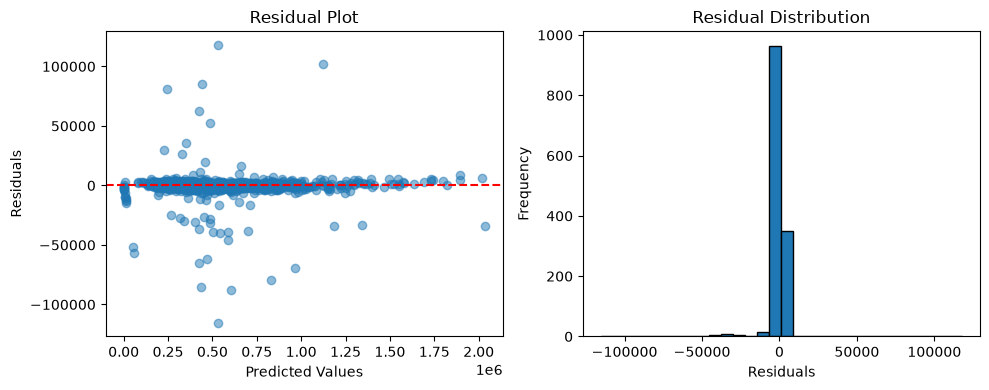

In [99]:
#check residual pattern
import matplotlib.pyplot as plt

y_pred = pipeline.predict(x_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))

# Residual plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# Distribution
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

# Should see: random scatter around 0, normal distribution


## What This Means
### This model is excellent for ~95% of predictions.